# RETO : CREAR UN MODELO DE MACHINE LEARNIGN PARA PREDECIR EL PRECIO DE UN AUTO USANDO ESTE DATASET

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alemazz11/cars-europe")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars-europe' dataset.
Path to dataset files: /kaggle/input/cars-europe


In [ ]:
!ls /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1

fullGas.csv


In [ ]:
PATH_CSV = path + "/fullGas.csv"

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
sns.set(style='whitegrid',context='notebook')

In [ ]:
df = pd.read_csv(PATH_CSV)
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,NaN,...,NaN,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,NaN,...,4.0,5.0,5.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,NaN,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,NaN,...,3.0,5.0,5.0,Black,Cloth,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [ ]:
df.isna().sum().sum()

np.int64(103838)

In [ ]:
df.isnull().sum()

,0
Make,0
Model,221
Body,1
Mileage_km,0
Price,0
Year,1695
Country,2592
Condition,0
Fuel_Type,29
Fuel_Consumption_l,27721


In [ ]:
df = df.ffill()

In [ ]:
df = df.bfill()

In [ ]:
df = df.drop(columns=["Image_url"])

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Body,0
Mileage_km,0
Price,0
Year,0
Country,0
Condition,0
Fuel_Type,0
Fuel_Consumption_l,0


In [ ]:
df.dtypes

,0
Make,object
Model,object
Body,object
Mileage_km,int64
Price,int64
Year,float64
Country,object
Condition,object
Fuel_Type,object
Fuel_Consumption_l,float64


In [ ]:
cat_columns = df.select_dtypes(object).columns
cat_columns

Index(['Make', 'Model', 'Body', 'Country', 'Condition', 'Fuel_Type',
       'Drivetrain', 'Gearbox', 'Color', 'Upholstery', 'Seller'],
      dtype='object')

In [ ]:
for cc in cat_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Make
Bentley          958
Citroen          942
Alfa Romeo       940
Jeep             931
Mazda            931
Jaguar           930
Aston Martin     927
Volvo            926
Toyota           924
SEAT             924
Lancia           922
Land Rover       921
Chevrolet        919
Abarth           918
MINI             917
MG               916
Fiat             914
Audi             914
BMW              909
Porsche          909
Opel             908
BYD              906
Dodge            905
Kia              905
Lexus            901
Peugeot          901
CUPRA            899
smart            898
Maserati         897
Tesla            897
Dacia            894
Lamborghini      893
Suzuki           891
Honda            890
Renault          884
Ferrari          884
Mitsubishi       882
Nissan           881
Hyundai          877
Ford             874
Skoda            856
Mercedes-Benz    796
Volkswagen       787
Rolls-Royce      636
Corvette         614

In [ ]:
ordinal_cols = ['Condition','Seller']
onehot_cols = list(set(cat_columns) - set(ordinal_cols))
print(f'ordinal cols : {ordinal_cols}')
print(f'onehot cols : {onehot_cols}')

ordinal cols : ['Condition', 'Seller']
onehot cols : ['Upholstery', 'Drivetrain', 'Body', 'Make', 'Country', 'Model', 'Fuel_Type', 'Gearbox', 'Color']


In [ ]:
import sklearn.compose
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
numeric_bool_cols = [
    'Mileage_km', 'Year', 'Fuel_Consumption_l', 'Gears', 'Power_hp',
    'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors', 'Full_Service_History',
    'Non_Smoker_Vehicle', 'Previous_Owners'
]

transformers_list = [
    ('ordinal_enc', OrdinalEncoder(), ordinal_cols),
    ('onehot_enc', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), onehot_cols),
    ('scaler', StandardScaler(), numeric_bool_cols)
]

transformer = ColumnTransformer(
    transformers=transformers_list,
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal_enc', OrdinalEncoder(),
                                 ['Condition', 'Seller']),
                                ('onehot_enc',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Upholstery', 'Drivetrain', 'Body', 'Make',
                                  'Country', 'Model', 'Fuel_Type', 'Gearbox',
                                  'Color']),
                                ('scaler', StandardScaler(),
                                 ['Mileage_km', 'Year', 'Fuel_Consumption_l',
                                  'Gears', 'Power_hp', 'Engine_Size_cc',
                                  'Cylinders', 'Seats', 'Doors',
                                  'Full_Service_History', 'Non_Smoker_Vehicle',
                                  'Previous_Owners'])])

In [ ]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinal_enc__Condition,ordinal_enc__Seller,onehot_enc__Upholstery_Cloth,onehot_enc__Upholstery_Full leather,onehot_enc__Upholstery_Other,onehot_enc__Upholstery_Part leather,onehot_enc__Upholstery_Velour,onehot_enc__Upholstery_alcantara,onehot_enc__Drivetrain_4WD,onehot_enc__Drivetrain_Front Wheel Drive,...,scaler__Gears,scaler__Power_hp,scaler__Engine_Size_cc,scaler__Cylinders,scaler__Seats,scaler__Doors,scaler__Full_Service_History,scaler__Non_Smoker_Vehicle,scaler__Previous_Owners,remainder__Price
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,-0.290905,-0.572614,-0.291827,-0.376339,-1.110611,-0.962761,-0.931514,2.209585,16900.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,-0.368716,-0.572614,-0.291827,-0.376339,-1.110611,-0.962761,1.073521,2.209585,12500.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,0.381611,-0.572614,-0.291827,-0.376339,-1.110611,1.038679,1.073521,-0.362347,17990.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,-0.396506,-0.572614,-0.291827,-0.376339,-1.110611,1.038679,1.073521,0.494964,9300.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.109767,-0.479876,-0.572614,-0.291827,-0.376339,-1.110611,1.038679,1.073521,-0.362347,14990.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-2.237814,-0.190861,-0.188089,1.417348,0.234021,0.677476,1.038679,1.073521,-0.362347,32990.0
40490,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.048799,-0.190861,-0.188089,-0.291827,0.234021,0.677476,-0.962761,-0.931514,-0.362347,26990.0
40491,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.048799,-0.229767,-0.188089,-0.291827,0.234021,0.677476,1.038679,1.073521,0.494964,32490.0
40492,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.579283,-0.113049,-0.502875,-0.719120,0.234021,0.677476,1.038679,-0.931514,0.494964,29450.0


In [ ]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinal_enc__", "").replace("onehot_enc__", "").replace("scaler__", "").replace("remainder__", "")
)

data_transformed_df

,Condition,Seller,Upholstery_Cloth,Upholstery_Full leather,Upholstery_Other,Upholstery_Part leather,Upholstery_Velour,Upholstery_alcantara,Drivetrain_4WD,Drivetrain_Front Wheel Drive,...,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Price
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,-0.290905,-0.572614,-0.291827,-0.376339,-1.110611,-0.962761,-0.931514,2.209585,16900.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,-0.368716,-0.572614,-0.291827,-0.376339,-1.110611,-0.962761,1.073521,2.209585,12500.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,0.381611,-0.572614,-0.291827,-0.376339,-1.110611,1.038679,1.073521,-0.362347,17990.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.359749,-0.396506,-0.572614,-0.291827,-0.376339,-1.110611,1.038679,1.073521,0.494964,9300.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.109767,-0.479876,-0.572614,-0.291827,-0.376339,-1.110611,1.038679,1.073521,-0.362347,14990.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-2.237814,-0.190861,-0.188089,1.417348,0.234021,0.677476,1.038679,1.073521,-0.362347,32990.0
40490,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.048799,-0.190861,-0.188089,-0.291827,0.234021,0.677476,-0.962761,-0.931514,-0.362347,26990.0
40491,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.048799,-0.229767,-0.188089,-0.291827,0.234021,0.677476,1.038679,1.073521,0.494964,32490.0
40492,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.579283,-0.113049,-0.502875,-0.719120,0.234021,0.677476,1.038679,-0.931514,0.494964,29450.0


In [ ]:
data_transformed_df.dtypes

,0
Condition,float64
Seller,float64
Upholstery_Cloth,float64
Upholstery_Full leather,float64
Upholstery_Other,float64
...,...
Doors,float64
Full_Service_History,float64
Non_Smoker_Vehicle,float64
Previous_Owners,float64


In [ ]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Power_hp,0.468264
Cylinders,0.392796
Engine_Size_cc,0.349928
Model_Enzo Ferrari,0.324533
...,...
Gearbox_Manual,-0.136231
Upholstery_Cloth,-0.161115
Seats,-0.185502
Drivetrain_Front Wheel Drive,-0.223208


<Axes: >

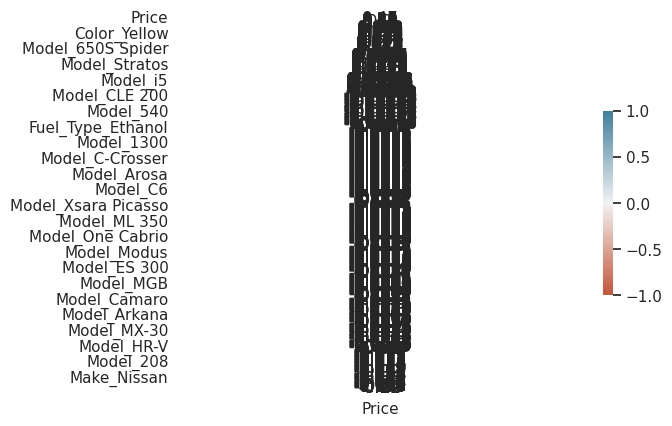

In [ ]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [ ]:
X_cols = corr_charges.index.tolist()
X_cols.remove('Price')
y_col = ['Price']

In [ ]:
X = data_transformed_df[X_cols].values
y = data_transformed_df[y_col].values.reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='linear'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [ ]:
results = {}
for name,model in models.items():
    model.fit(X_train_scaled,y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)

    r2 = r2_score(y_test_scaled,y_pred_scaled)
    mse = mean_squared_error(y_test_scaled,y_pred_scaled)
    mae = mean_absolute_error(y_test_scaled,y_pred_scaled)
    results[name] = {"R2":r2,"MSE":mse,"MAE":mae}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
results_df = pd.DataFrame(results).T
results_df

In [ ]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")